In [1]:
import pandas as pd

In [2]:
from pathlib import Path

In [3]:
file_path = Path.home() / "Desktop" / "BA_forage" / "customer_booking.csv"

In [4]:
df = pd.read_csv(file_path, encoding="latin-1")

In [5]:
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [6]:
df["origin_airport"] = df["route"].str[:3]

In [7]:
df["destination_airport"] = df["route"].str[-3:]

In [8]:
!pip install folium airportsdata

In [9]:
import folium
import airportsdata

In [10]:
airports = airportsdata.load("IATA")

In [11]:
print(airports.get("PNH"))

None


In [12]:
def get_coordinate(code, coordinate):
    airport = airports.get(code, {})
    return airport.get(coordinate)

In [13]:
df["origin_lat"] = df["origin_airport"].map(
    lambda code: get_coordinate(code, "lat")
)

df["origin_lon"] = df["origin_airport"].map(
    lambda code: get_coordinate(code, "lon")
)

df["destination_lat"] = df["destination_airport"].map(
    lambda code: get_coordinate(code, "lat")
)

df["destination_lon"] = df["destination_airport"].map(
    lambda code: get_coordinate(code, "lon")
)

In [14]:
df[[
    "route",
    "origin_airport",
    "origin_lat",
    "origin_lon",
    "destination_airport",
    "destination_lat",
    "destination_lon"
]].head(10)

,route,origin_airport,origin_lat,origin_lon,destination_airport,destination_lat,destination_lon
0,AKLDEL,AKL,-37.0081,174.79201,DEL,28.5665,77.1031
1,AKLDEL,AKL,-37.0081,174.79201,DEL,28.5665,77.1031
2,AKLDEL,AKL,-37.0081,174.79201,DEL,28.5665,77.1031
3,AKLDEL,AKL,-37.0081,174.79201,DEL,28.5665,77.1031
4,AKLDEL,AKL,-37.0081,174.79201,DEL,28.5665,77.1031
5,AKLDEL,AKL,-37.0081,174.79201,DEL,28.5665,77.1031
6,AKLDEL,AKL,-37.0081,174.79201,DEL,28.5665,77.1031
7,AKLDEL,AKL,-37.0081,174.79201,DEL,28.5665,77.1031
8,AKLDEL,AKL,-37.0081,174.79201,DEL,28.5665,77.1031
9,AKLDEL,AKL,-37.0081,174.79201,DEL,28.5665,77.1031


In [15]:
m = folium.Map(
    location=[20, 0],
    zoom_start=2
)

In [16]:
origin_counts = (
    df.groupby(
        ["origin_airport", "origin_lat", "origin_lon"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "booking_count"})
)

In [17]:
for _, row in origin_counts.iterrows():
    folium.CircleMarker(
        location=[row["origin_lat"], row["origin_lon"]],
        radius=row["booking_count"] ** 0.5 / 4,
        tooltip=f'{row["origin_airport"]}: {row["booking_count"]} bookings',
        popup=(
            f'Airport: {row["origin_airport"]}<br>'
            f'Bookings: {row["booking_count"]}'
        ),
        color="black", 
        weight=1,
        fill=True,
        fill_color="skyblue",    
        fill_opacity=0.5 
    ).add_to(m)

In [18]:
m.save("airport_map_orig.html")

In [19]:
destination_counts = (
    df.groupby(
        ["destination_airport", "destination_lat", "destination_lon"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "booking_count"})
)

In [20]:
for _, row in destination_counts.iterrows():
    folium.CircleMarker(
        location=[row["destination_lat"], row["destination_lon"]],
        radius=row["booking_count"] ** 0.5 / 4,
        tooltip=f'{row["destination_airport"]}: {row["booking_count"]} bookings',
        popup=(
            f'Airport: {row["destination_airport"]}<br>'
            f'Bookings: {row["booking_count"]}'
        ),
        color="black",         
        weight=1,              
        fill=True,
        fill_color="orange",  
        fill_opacity=0.5         
    ).add_to(m)

In [21]:
m.save("airport_map.html")

In [22]:
df.columns.tolist()

['num_passengers',
 'sales_channel',
 'trip_type',
 'purchase_lead',
 'length_of_stay',
 'flight_hour',
 'flight_day',
 'route',
 'booking_origin',
 'wants_extra_baggage',
 'wants_preferred_seat',
 'wants_in_flight_meals',
 'flight_duration',
 'booking_complete',
 'origin_airport',
 'destination_airport',
 'origin_lat',
 'origin_lon',
 'destination_lat',
 'destination_lon']

In [23]:
country_counts = (
    df.groupby("booking_origin", as_index=False)
      .size()
      .rename(columns={"size": "booking_count"})
)

In [24]:
country_counts["booking_origin"] = country_counts["booking_origin"].replace(
    "(not set)",
    "Unknown"
)

In [25]:
country_counts.head(10)

,booking_origin,booking_count
0,Unknown,84
1,Afghanistan,1
2,Algeria,1
3,Argentina,6
4,Australia,17872
5,Austria,8
6,Bahrain,5
7,Bangladesh,36
8,Belarus,1
9,Belgium,7


In [26]:
country_map = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles="CartoDB positron"
)

In [27]:
folium.Choropleth(
    geo_data=(
        "https://raw.githubusercontent.com/python-visualization/"
        "folium/master/examples/data/world-countries.json"
    ),
    data=country_counts,
    columns=["booking_origin", "booking_count"],
    key_on="feature.properties.name",
    fill_color="GnBu",
    fill_opacity=0.8,
    line_color="grey",
    line_weight=0.7,
    line_opacity=0.8,
    nan_fill_color="lightgrey",
    nan_fill_opacity=0.4,
    legend_name="Number of bookings"
).add_to(country_map)

In [28]:
country_map.save("bookings_by_country.html")

In [29]:
booking_origin_counts = df["booking_origin"].value_counts()

In [30]:
df["booking_origin_new"] = df["booking_origin"].apply(
    lambda country: (
        country
        if booking_origin_counts[country] > 1000 or country == "Unknown"
        else "Other"
    )
)

In [31]:
df["booking_origin"] = df["booking_origin"].replace(
    "(not set)",
    "Unknown"
)

booking_origin_counts = df["booking_origin"].value_counts()

df["booking_origin_new"] = df["booking_origin"].apply(
    lambda country: (
        country
        if booking_origin_counts[country] > 1000 or country == "Unknown"
        else "Other"
    )
)

In [32]:
df[["booking_origin", "booking_origin_new"]].head(20)

,booking_origin,booking_origin_new
0,New Zealand,New Zealand
1,New Zealand,New Zealand
2,India,India
3,New Zealand,New Zealand
4,India,India
5,New Zealand,New Zealand
6,New Zealand,New Zealand
7,India,India
8,New Zealand,New Zealand
9,India,India


In [33]:
df["booking_origin_new"].value_counts()

booking_origin_new
Australia      17872
Malaysia        7174
South Korea     4559
Japan           3885
China           3387
Other           3175
Indonesia       2369
Taiwan          2077
Thailand        2030
India           1270
New Zealand     1074
Singapore       1044
Unknown           84
Name: count, dtype: int64

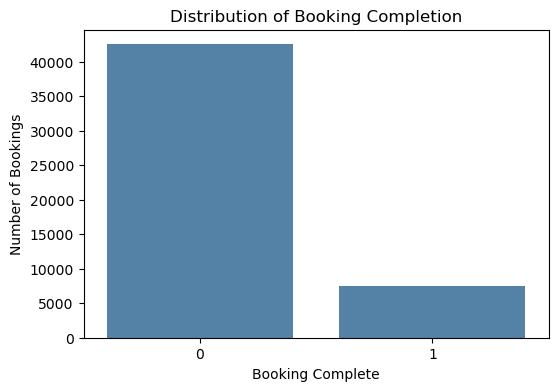

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="booking_complete",
    color="steelblue"
)

plt.title("Distribution of Booking Completion")
plt.xlabel("Booking Complete")
plt.ylabel("Number of Bookings")

plt.show()

In [35]:
df["booking_complete"].value_counts(normalize=True) * 100

booking_complete
0    85.044
1    14.956
Name: proportion, dtype: float64

In [36]:
df["flight_day"].value_counts().sort_index()

flight_day
Fri    6761
Mon    8102
Sat    5812
Sun    6554
Thu    7424
Tue    7673
Wed    7674
Name: count, dtype: int64

In [37]:
df["flight_day_group"] = df["flight_day"].apply(
    lambda day: "Weekend" if day in ["Sat", "Sun"] else "Weekday"
)

In [38]:
df[["flight_day", "flight_day_group"]].head(10)

,flight_day,flight_day_group
0,Sat,Weekend
1,Sat,Weekend
2,Wed,Weekday
3,Sat,Weekend
4,Wed,Weekday
5,Thu,Weekday
6,Thu,Weekday
7,Mon,Weekday
8,Mon,Weekday
9,Sun,Weekend


In [39]:
df["flight_day_group"].value_counts()

flight_day_group
Weekday    37634
Weekend    12366
Name: count, dtype: int64

In [40]:
features = [
    "booking_origin_new",
    "purchase_lead",
    "length_of_stay",
    "flight_hour",
    "flight_duration",
    "sales_channel",
    "trip_type",
    "flight_day_group",
    "wants_extra_baggage",
    "wants_preferred_seat",
    "wants_in_flight_meals"
]

In [41]:
target = "booking_complete"

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=12345,
    stratify=df["booking_complete"]
)

In [44]:
validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=12345,
    stratify=temp_df["booking_complete"]
)

In [45]:
# Count observations in each class using the training set
class_counts = train_df["booking_complete"].value_counts()

# Total number of training observations
N = len(train_df)

# Number of classes
K = train_df["booking_complete"].nunique()

# Calculate inverse-frequency class weights
class_weights = {
    class_value: N / (K * class_count)
    for class_value, class_count in class_counts.items()
}

class_weights

{0: 0.5879388543591466, 1: 3.3428844317096464}

In [46]:
train_df["class_weight"] = (
    train_df["booking_complete"].map(class_weights)
)

validation_df["class_weight"] = (
    validation_df["booking_complete"].map(class_weights)
)

test_df["class_weight"] = (
    test_df["booking_complete"].map(class_weights)
)

In [47]:
X_train = pd.get_dummies(
    train_df[features],
    drop_first=True,
    dtype=int
)

X_validation = pd.get_dummies(
    validation_df[features],
    drop_first=True,
    dtype=int
)

X_test = pd.get_dummies(
    test_df[features],
    drop_first=True,
    dtype=int
)

In [48]:
X_validation = X_validation.reindex(
    columns=X_train.columns,
    fill_value=0
)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [49]:
y_train = train_df[target]
y_validation = validation_df[target]
y_test = test_df[target]

In [50]:
weight_train = train_df["class_weight"]
weight_validation = validation_df["class_weight"]
weight_test = test_df["class_weight"]

In [51]:
from sklearn.tree import DecisionTreeClassifier

In [52]:
tree_model = DecisionTreeClassifier(
    min_samples_split=50,
    random_state=12345
)

In [53]:
tree_model.fit(
    X_train,
    y_train,
    sample_weight=weight_train
)

DecisionTreeClassifier(min_samples_split=50, random_state=12345)

In [54]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

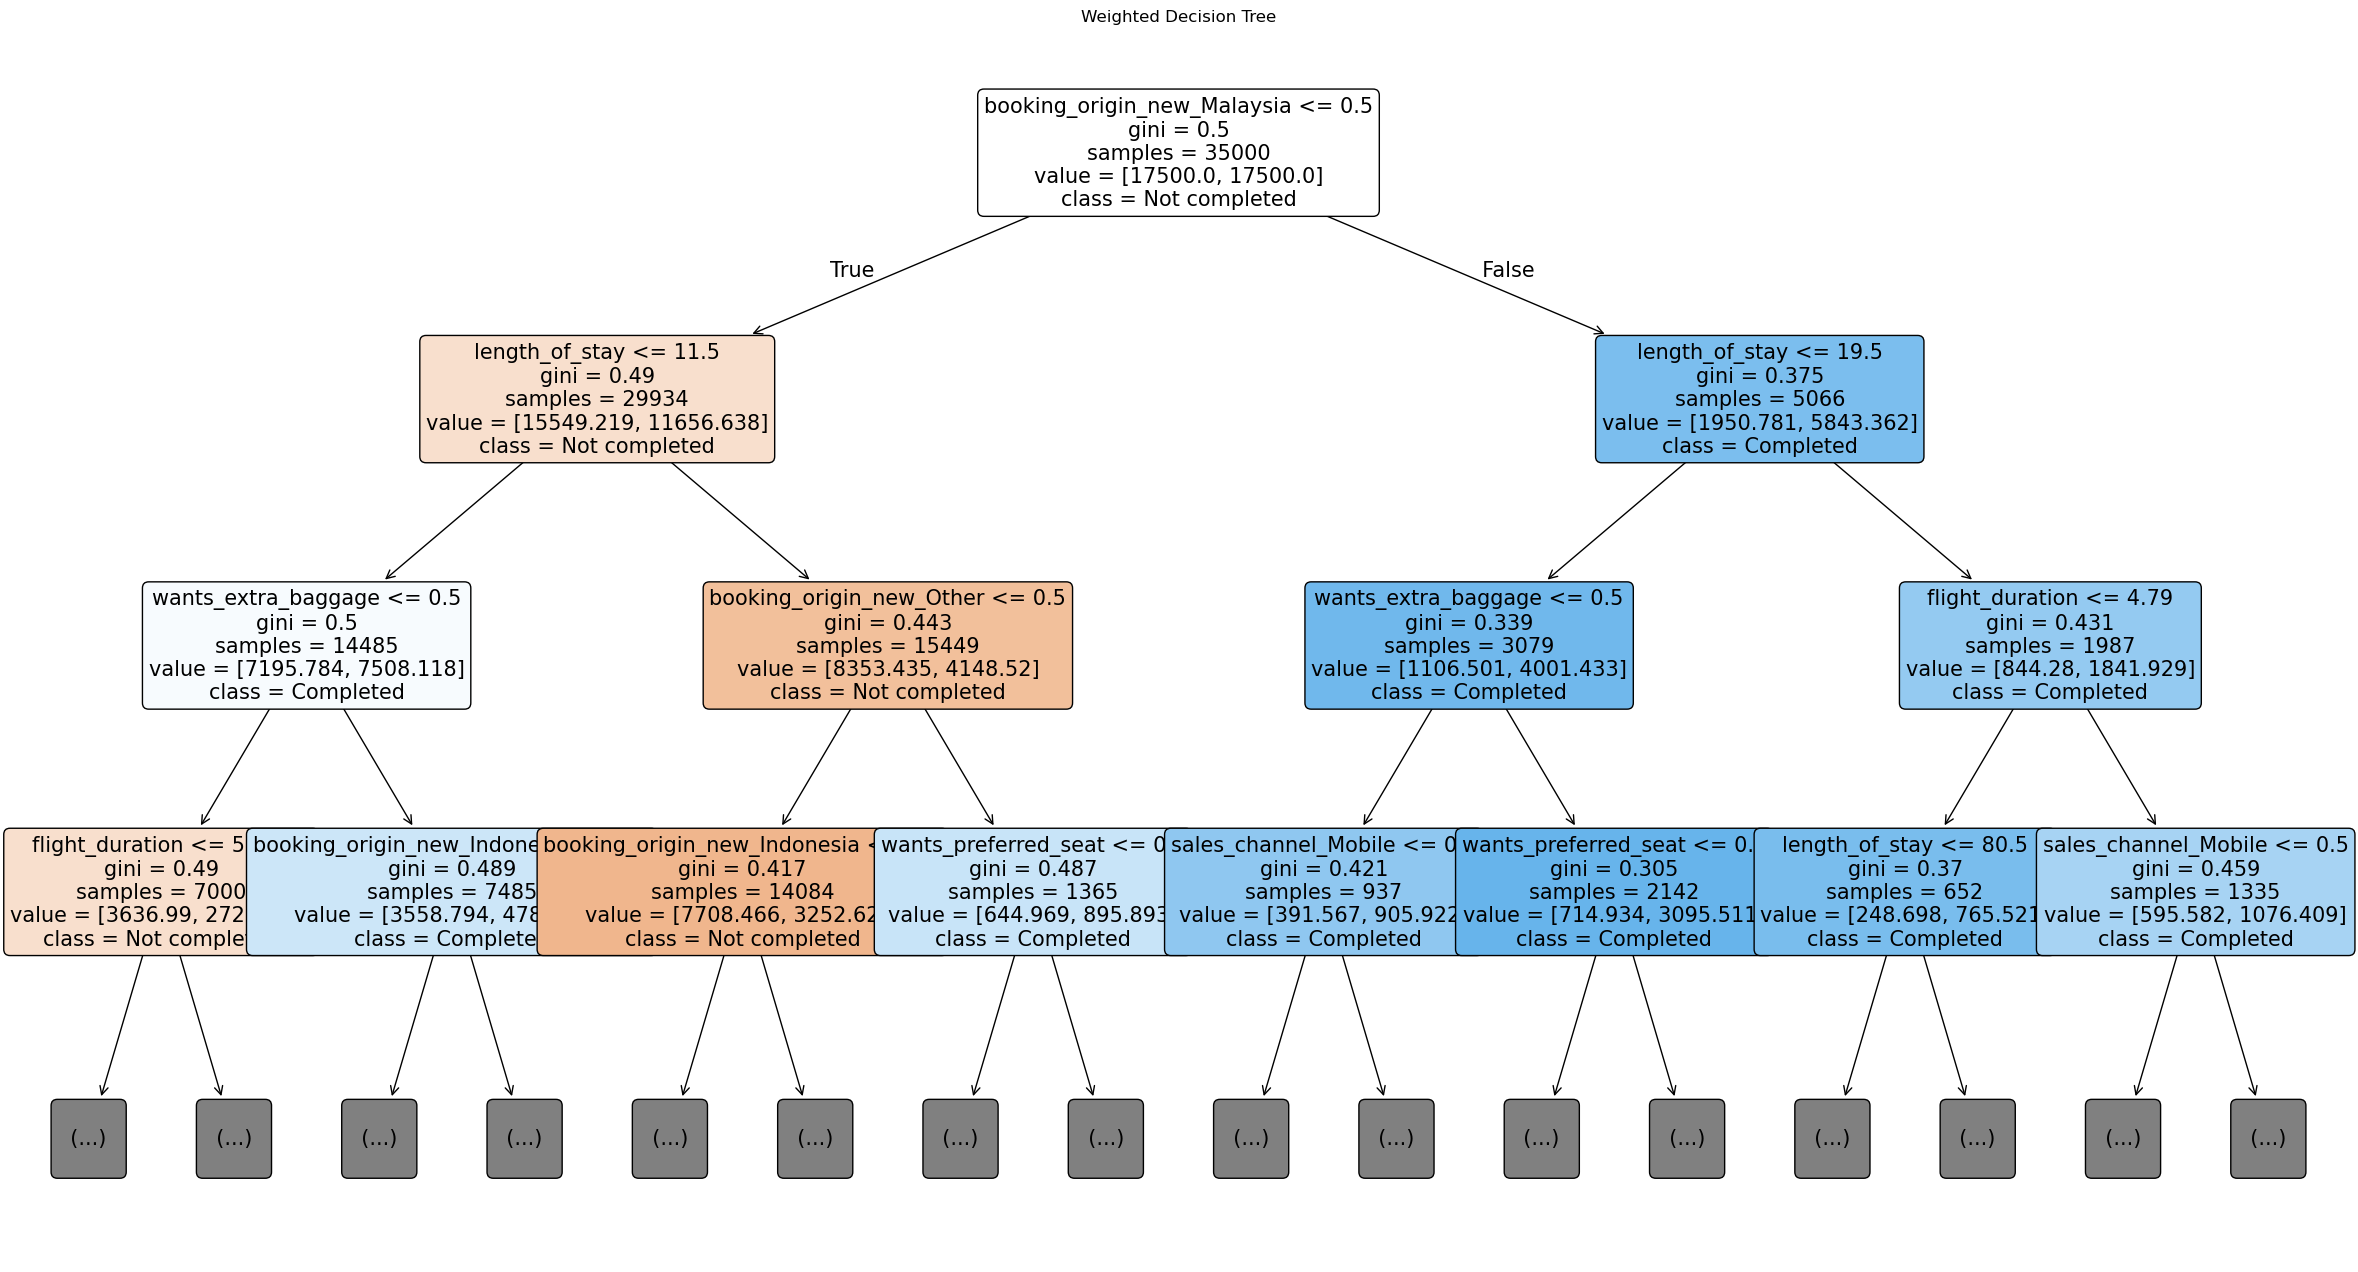

In [55]:
plt.figure(figsize=(30, 16))

plot_tree(
    tree_model,
    feature_names=X_train.columns,
    class_names=["Not completed", "Completed"],
    filled=True,
    rounded=True,
    fontsize=15,
    max_depth=3
)

plt.title("Weighted Decision Tree")
plt.show()

In [56]:
# Predicted classes
y_pred = tree_model.predict(X_validation)

# Predicted probabilities
y_prob = tree_model.predict_proba(X_validation)[:, 1]

In [57]:
from sklearn.metrics import accuracy_score, roc_auc_score

In [58]:
accuracy = accuracy_score(y_validation, y_pred)

auc = roc_auc_score(y_validation, y_prob)

print(f"Accuracy: {accuracy:.3f}")
print(f"ROC AUC: {auc:.3f}")

Accuracy: 0.668
ROC AUC: 0.686


In [59]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

In [60]:
fpr, tpr, thresholds = roc_curve(y_validation, y_prob)

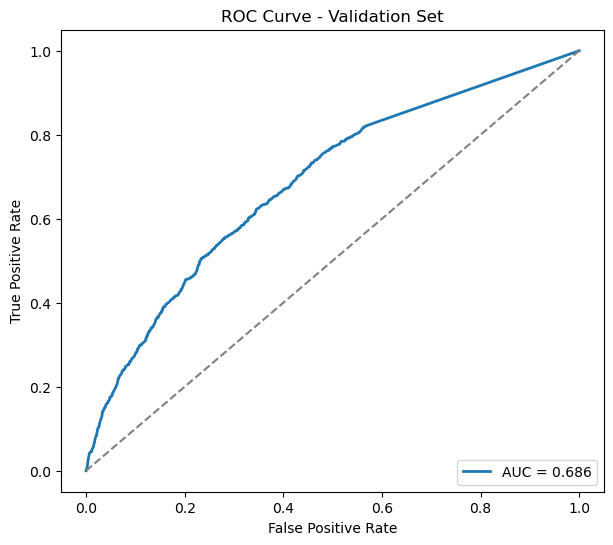

In [61]:
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}",
    linewidth=2
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Validation Set")
plt.legend(loc="lower right")

plt.show()

Bootstrap Forest

In [62]:
from sklearn.ensemble import RandomForestClassifier

bootstrap_forest = RandomForestClassifier(
    n_estimators=37,
    max_features=8,
    min_samples_split=50,
    bootstrap=True,
    max_samples=1.0,
    random_state=12345,
    n_jobs=-1
)

In [63]:
bootstrap_forest.fit(
    X_train,
    y_train,
    sample_weight=weight_train
)

RandomForestClassifier(max_features=8, max_samples=1.0, min_samples_split=50,
                       n_estimators=37, n_jobs=-1, random_state=12345)

In [64]:
# Predicted classes
y_pred_rf = bootstrap_forest.predict(X_validation)

# Predicted probabilities
y_prob_rf = bootstrap_forest.predict_proba(X_validation)[:, 1]

In [65]:
accuracy_rf = accuracy_score(y_validation, y_pred_rf)

auc_rf = roc_auc_score(y_validation, y_prob_rf)

print(f"Bootstrap Forest Accuracy: {accuracy_rf:.3f}")
print(f"Bootstrap Forest ROC AUC: {auc_rf:.3f}")

Bootstrap Forest Accuracy: 0.740
Bootstrap Forest ROC AUC: 0.758


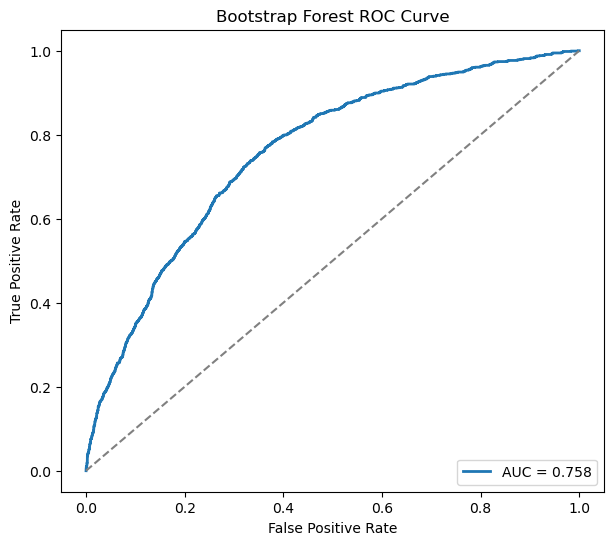

In [66]:
from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_validation,
    y_prob_rf
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"AUC = {auc_rf:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Bootstrap Forest ROC Curve")
plt.legend(loc="lower right")

plt.show()

In [67]:
print("Model Comparison")
print("---------------------------")
print(f"Decision Tree")
print(f"  Accuracy : {accuracy:.3f}")
print(f"  ROC AUC  : {auc:.3f}")

print()

print(f"Bootstrap Forest")
print(f"  Accuracy : {accuracy_rf:.3f}")
print(f"  ROC AUC  : {auc_rf:.3f}")

Model Comparison
---------------------------
Decision Tree
  Accuracy : 0.668
  ROC AUC  : 0.686

Bootstrap Forest
  Accuracy : 0.740
  ROC AUC  : 0.758


Logistic Regression

In [68]:
from sklearn.linear_model import LogisticRegression

In [69]:
logistic_model = LogisticRegression(
    random_state=12345,
    max_iter=5000
)

In [70]:
logistic_model.fit(
    X_train,
    y_train,
    sample_weight=weight_train
)

LogisticRegression(max_iter=5000, random_state=12345)

In [71]:
y_pred_log = logistic_model.predict(X_validation)

y_prob_log = logistic_model.predict_proba(X_validation)[:, 1]

In [72]:
accuracy_log = accuracy_score(
    y_validation,
    y_pred_log
)

auc_log = roc_auc_score(
    y_validation,
    y_prob_log
)

print(f"Logistic Regression Accuracy: {accuracy_log:.3f}")
print(f"Logistic Regression ROC AUC: {auc_log:.3f}")

Logistic Regression Accuracy: 0.679
Logistic Regression ROC AUC: 0.741


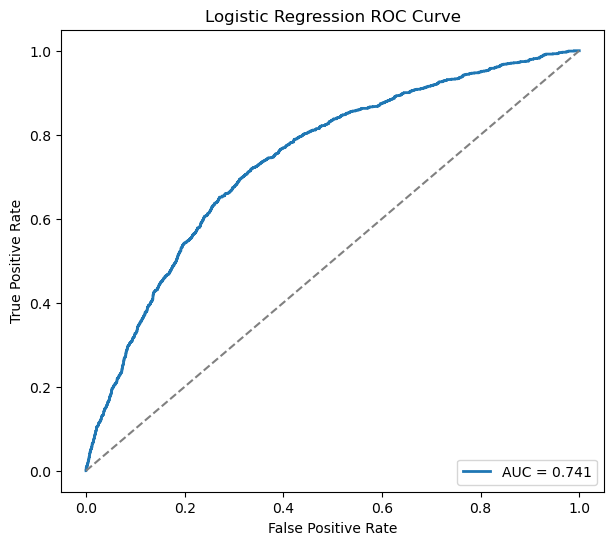

In [73]:
fpr_log, tpr_log, thresholds_log = roc_curve(
    y_validation,
    y_prob_log
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"AUC = {auc_log:.3f}",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend(loc="lower right")

plt.show()

In [74]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Bootstrap Forest",
        "Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        accuracy_rf,
        accuracy_log
    ],
    "ROC AUC": [
        auc,
        auc_rf,
        auc_log
    ]
})

comparison

,Model,Accuracy,ROC AUC
0,Decision Tree,0.667867,0.686212
1,Bootstrap Forest,0.739867,0.757869
2,Logistic Regression,0.679200,0.740631


Neural Networks

In [75]:
import sklearn
print(sklearn.__version__)

1.6.1


In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_validation_scaled = scaler.transform(X_validation)

X_test_scaled = scaler.transform(X_test)

In [77]:
from sklearn.neural_network import MLPClassifier

neural_model = MLPClassifier(
    hidden_layer_sizes=(7,),
    activation="tanh",
    random_state=12345,
    max_iter=1000
)

In [79]:
neural_model.fit(
    X_train_scaled,
    y_train
)

MLPClassifier(activation='tanh', hidden_layer_sizes=(7,), max_iter=1000,
              random_state=12345)

In [80]:
# Predicted classes
y_pred_nn = neural_model.predict(X_validation_scaled)

# Probability of class 1: booking completed
y_prob_nn = neural_model.predict_proba(X_validation_scaled)[:, 1]

In [81]:
accuracy_nn = accuracy_score(
    y_validation,
    y_pred_nn
)

auc_nn = roc_auc_score(
    y_validation,
    y_prob_nn
)

print(f"Neural Network Accuracy: {accuracy_nn:.3f}")
print(f"Neural Network ROC AUC: {auc_nn:.3f}")

Neural Network Accuracy: 0.852
Neural Network ROC AUC: 0.754


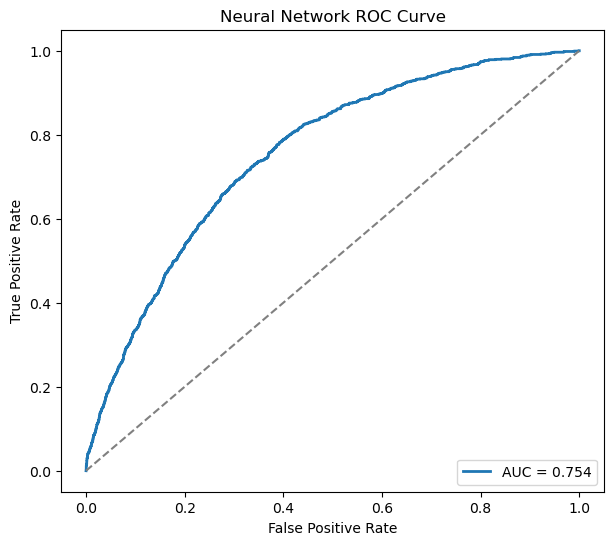

In [82]:
fpr_nn, tpr_nn, thresholds_nn = roc_curve(
    y_validation,
    y_prob_nn
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_nn,
    tpr_nn,
    linewidth=2,
    label=f"AUC = {auc_nn:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Neural Network ROC Curve")
plt.legend(loc="lower right")

plt.show()

In [83]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Bootstrap Forest",
        "Logistic Regression",
        "Neural Network"
    ],
    "Accuracy": [
        accuracy,
        accuracy_rf,
        accuracy_log,
        accuracy_nn
    ],
    "ROC AUC": [
        auc,
        auc_rf,
        auc_log,
        auc_nn
    ]
})

comparison = comparison.sort_values(
    by="ROC AUC",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Accuracy,ROC AUC
0,Bootstrap Forest,0.739867,0.757869
1,Neural Network,0.852000,0.753735
2,Logistic Regression,0.679200,0.740631
3,Decision Tree,0.667867,0.686212


In [84]:
comparison.round(3)

,Model,Accuracy,ROC AUC
0,Bootstrap Forest,0.740,0.758
1,Neural Network,0.852,0.754
2,Logistic Regression,0.679,0.741
3,Decision Tree,0.668,0.686
